# 03 · Results and error analysis

All experiments, compared on the same deduplicated test set (1,231 texts). Results come from
`results/experiments.csv`, written by `src/baseline.py`, `src/bilstm.py` (run locally) and
`src/transformer.py` (run on a Colab T4, notebook 02). Neural models were trained with 3 seeds;
the table reports mean ± standard deviation. **Models are chosen on the dev set only.** The test
set is used once, for the final numbers.

Main metric: **macro-F1** over the six emotions (the SemEval-2025 Task 11 Track A metric).

In [1]:
import os, sys, json, warnings
warnings.filterwarnings("ignore")
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from src.config import EMOTIONS, PROCESSED_DIR

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "axes.edgecolor": "#898781",
    "axes.labelcolor": "#52514e", "xtick.color": "#52514e", "ytick.color": "#52514e",
    "text.color": "#0b0b0b", "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "figure.dpi": 110})
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"]
GROUP_COLOR = {"Baseline": SERIES[0], "BiLSTM": SERIES[1], "Transformer": SERIES[2]}
pd.set_option("display.max_colwidth", 110)

## 1. All experiments

In [2]:
ex = pd.read_csv("results/experiments.csv")
cfg = ex["config"].map(json.loads)
ex["std"] = cfg.map(lambda c: c.get("test_macro_f1_std"))
ex["group"] = ex["experiment"].str[0].map({"B": "Baseline", "L": "BiLSTM", "T": "Transformer"})
ex["id"] = ex["experiment"].str.split("_").str[0]
NAMES = {
    "B0": "Random (label frequency)", "B1": "Word TF-IDF + LogReg, threshold 0.5",
    "B2": "+ class weights + tuned thresholds", "B3": "Char TF-IDF + LogReg", "B4": "Word+char TF-IDF + LogReg",
    "L1": "BiLSTM, random embeddings", "L2": "BiLSTM, Word2Vec frozen", "L3": "BiLSTM, Word2Vec fine-tuned",
    "L4": "BiLSTM, Word2Vec + attention", "T1": "XLM-R base (no Kinyarwanda)", "T2": "AfriBERTa large",
    "T3": "AfroXLMR base", "T4": "AfroXLMR large", "T5": "AfroXLMR base + LoRA"}
ex["model"] = ex["id"].map(NAMES)
table = ex[["id", "model", "dev_macro_f1", "test_macro_f1", "std", "test_micro_f1", "test_exact_match"]].round(3)
table

,id,model,dev_macro_f1,test_macro_f1,std,test_micro_f1,test_exact_match
0,B0,Random (label frequency),0.140,0.124,NaN,0.166,0.184
1,B1,"Word TF-IDF + LogReg, threshold 0.5",0.198,0.208,NaN,0.348,0.403
2,B2,+ class weights + tuned thresholds,0.486,0.466,NaN,0.492,0.330
3,B3,Char TF-IDF + LogReg,0.524,0.504,NaN,0.513,0.342
4,B4,Word+char TF-IDF + LogReg,0.534,0.511,NaN,0.508,0.374
5,L1,"BiLSTM, random embeddings",0.452,0.413,0.008,0.442,0.311
6,L2,"BiLSTM, Word2Vec frozen",0.518,0.465,0.003,0.486,0.347
7,L3,"BiLSTM, Word2Vec fine-tuned",0.511,0.478,0.007,0.488,0.376
8,L4,"BiLSTM, Word2Vec + attention",0.516,0.458,0.009,0.495,0.382
9,T1,XLM-R base (no Kinyarwanda),0.395,0.363,0.050,0.352,0.155


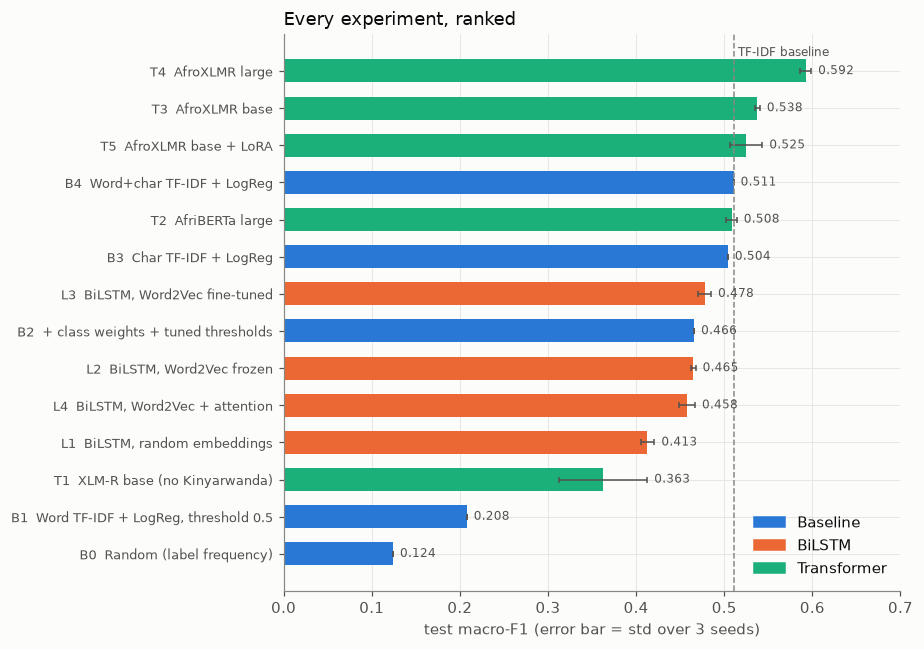

In [3]:
order = ex.sort_values("test_macro_f1")
fig, ax = plt.subplots(figsize=(8.5, 6))
y = np.arange(len(order))
bars = ax.barh(y, order["test_macro_f1"], xerr=order["std"].fillna(0), height=0.62,
               color=[GROUP_COLOR[g] for g in order["group"]], error_kw={"ecolor": "#52514e", "lw": 1, "capsize": 2})
for yi, v, s in zip(y, order["test_macro_f1"], order["std"].fillna(0)):
    ax.text(v + s + 0.008, yi, f"{v + 1e-9:.3f}", va="center", fontsize=8, color="#52514e")
ax.set_yticks(y, [f"{i}  {m}" for i, m in zip(order["id"], order["model"])], fontsize=8.5)
b4 = ex.loc[ex.id == "B4", "test_macro_f1"].item()
ax.axvline(b4, color="#898781", ls="--", lw=1)
ax.text(b4 + 0.005, len(order) - 0.6, "TF-IDF baseline", fontsize=8, color="#52514e")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=g) for g, c in GROUP_COLOR.items()], frameon=False, loc="lower right"); ax.set_xlim(0, 0.7)
ax.set_xlabel("test macro-F1 (error bar = std over 3 seeds)")
ax.set_title("Every experiment, ranked", loc="left")
plt.tight_layout(); plt.savefig("results/figures/all_experiments.png", dpi=150); plt.show()

## 2. What each comparison tells us

Each experiment changes **one thing** relative to another, so it answers one question.

In [4]:
def f1(i): return ex.loc[ex.id == i, "test_macro_f1"].item()
questions = [
    ("Does handling class imbalance matter?", "B1", "B2"),
    ("Do character n-grams beat words (agglutinative language)?", "B2", "B3"),
    ("Do pretrained Word2Vec embeddings help the BiLSTM?", "L1", "L3"),
    ("Does attention pooling beat max pooling?", "L3", "L4"),
    ("Does a BiLSTM beat TF-IDF on 2.4k texts?", "B4", "L3"),
    ("Does seeing Kinyarwanda in pretraining matter? (same architecture)", "T1", "T3"),
    ("Does a bigger model help with little data?", "T3", "T4"),
    ("Can LoRA (0.4% of weights) match full fine-tuning?", "T3", "T5"),
    ("Best Transformer vs best baseline", "B4", "T4"),
]
pd.DataFrame([{"question": q, "from": a, "to": b, "macro-F1 change": round(f1(b) - f1(a), 3)} for q, a, b in questions])

,question,from,to,macro-F1 change
0,Does handling class imbalance matter?,B1,B2,0.258
1,Do character n-grams beat words (agglutinative language)?,B2,B3,0.038
2,Do pretrained Word2Vec embeddings help the BiLSTM?,L1,L3,0.065
3,Does attention pooling beat max pooling?,L3,L4,-0.020
4,Does a BiLSTM beat TF-IDF on 2.4k texts?,B4,L3,-0.033
5,Does seeing Kinyarwanda in pretraining matter? (same architecture),T1,T3,0.175
6,Does a bigger model help with little data?,T3,T4,0.055
7,Can LoRA (0.4% of weights) match full fine-tuning?,T3,T5,-0.013
8,Best Transformer vs best baseline,B4,T4,0.082


- **Imbalance handling is the biggest single win (+0.26).** With a 0.5 threshold the model never predicts fear or surprise (F1 = 0).
- **Character n-grams help (+0.04).** One Kinyarwanda stem appears with many prefixes, and characters share evidence across them.
- **Word2Vec helps the BiLSTM (+0.065)** mostly through vocabulary coverage: unknown test words fall from 24.6% to 9.4%.
- **Attention does not help (−0.02).** Texts are ~18 words, so max pooling already finds the emotional words, and the extra parameters overfit.
- **The BiLSTM never beats TF-IDF.** 2.4k labelled texts are too few to train a recurrent network from scratch. More complex is not automatically better.
- **Pretraining on Kinyarwanda is the key factor (+0.17).** XLM-R and AfroXLMR-base have the same architecture and tokenizer; only AfroXLMR's extra African-language pretraining differs.
- **Scale helps even with little data (+0.05).** All three AfroXLMR-large seeds beat every base-model seed.
- **LoRA keeps ~98% of the score** while training 0.4% of the weights.

In [5]:
eff = ex[ex.id.isin(["T1", "T2", "T3", "T4", "T5"])].copy()
eff["trainable params (M)"] = cfg[eff.index].map(lambda c: c.get("trainable_params", 0) / 1e6).round(1)
eff["minutes per run (T4 GPU)"] = cfg[eff.index].map(lambda c: c.get("minutes_per_run"))
eff["best epochs (3 seeds)"] = cfg[eff.index].map(lambda c: c.get("epochs"))
eff[["id", "model", "trainable params (M)", "minutes per run (T4 GPU)", "best epochs (3 seeds)", "test_macro_f1", "std"]].round(3)

,id,model,trainable params (M),minutes per run (T4 GPU),best epochs (3 seeds),test_macro_f1,std
9,T1,XLM-R base (no Kinyarwanda),278.0,4.1,"[1, 8, 6]",0.363,0.050
10,T2,AfriBERTa large,125.6,2.5,"[6, 5, 5]",0.508,0.006
11,T3,AfroXLMR base,278.0,4.4,"[6, 5, 4]",0.538,0.003
12,T4,AfroXLMR large,559.9,12.1,"[7, 8, 6]",0.592,0.006
13,T5,AfroXLMR base + LoRA,1.2,1.6,"[4, 6, 3]",0.525,0.018


XLM-R's best epochs `[1, 8, 6]` show the **seed-42 collapse**: after epoch 1 its dev score fell and never
recovered, so the best checkpoint was the first. Fine-tuning instability on small datasets is a known
problem (Mosbach et al., 2021), and it is why every neural model was run with three seeds.

## 3. Per-emotion results

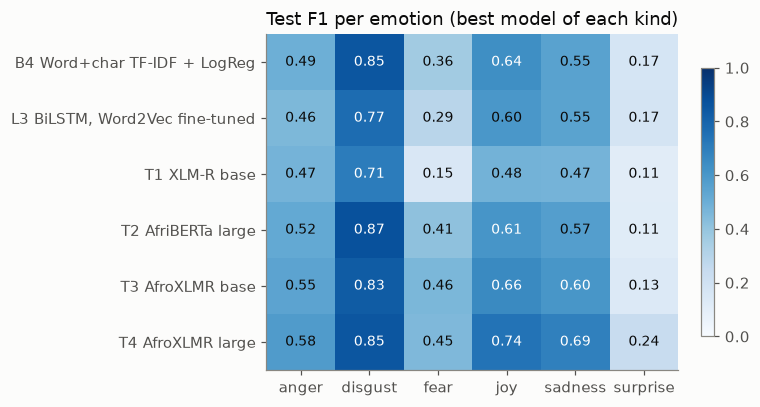

In [6]:
pe = pd.read_csv("results/error_analysis/per_emotion.csv")
pe["id"] = pe["experiment"].str.split("_").str[0]
heat = pe.pivot(index="id", columns="emotion", values="f1").loc[["B4", "L3", "T1", "T2", "T3", "T4"], EMOTIONS]
fig, ax = plt.subplots(figsize=(7, 3.8))
im = ax.imshow(heat.values, cmap="Blues", vmin=0, vmax=1, aspect="auto")
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = heat.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9, color="white" if v > 0.6 else "#0b0b0b")
ax.set_xticks(range(6), EMOTIONS); ax.set_yticks(range(len(heat)), [f"{i} {NAMES[i].split(' (')[0]}" for i in heat.index])
ax.grid(False); ax.set_title("Test F1 per emotion (best model of each kind)", loc="left")
fig.colorbar(im, fraction=0.03)
plt.tight_layout(); plt.savefig("results/figures/per_emotion_heatmap.png", dpi=150); plt.show()

In [7]:
best = pe[pe.id == "T4"].set_index("emotion")[["precision", "recall", "f1", "support", "predicted_count"]]
best

,precision,recall,f1,support,predicted_count
emotion,,,,,
anger,0.552,0.613,0.581,225,250
disgust,0.846,0.859,0.853,64,65
fear,0.409,0.500,0.450,72,88
joy,0.757,0.722,0.739,212,202
sadness,0.643,0.742,0.689,318,367
surprise,0.193,0.321,0.241,53,88


- AfroXLMR-large is best on anger, joy, sadness and surprise, and essentially ties on fear. Joy (0.74) and sadness (0.69) gain most from understanding the sentence.
- **Disgust is high for every model** (0.71–0.87). That is the dataset artefact from notebook 01: short, non-tweet, distinctive vocabulary.
- **Surprise stays the hardest** (≤ 0.24): 105 training examples, and surprise depends on what the reader expected rather than on particular words.
- **XLM-R without Kinyarwanda floods rare emotions.** It predicted fear 508 times for 72 true cases. With no real signal, threshold tuning made it fire constantly.

In [8]:
pe[(pe.id == "T1") & pe.emotion.isin(["fear", "surprise"])][["emotion", "precision", "recall", "support", "predicted_count"]]

,emotion,precision,recall,support,predicted_count
14,fear,0.087,0.611,72,508
17,surprise,0.061,0.585,53,510


## 4. Which emotions are confused?
Texts with exactly one gold emotion where the model did **not** find it: what it predicted instead.

In [9]:
conf = pd.read_csv("results/error_analysis/confusions.csv")
conf[conf.experiment.str.startswith("T4")].head(10)[["gold", "predicted_instead", "count"]]

,gold,predicted_instead,count
147,joy,none,38
148,anger,none,27
149,anger,sadness,24
150,sadness,none,21
151,sadness,anger,18
152,fear,none,11
153,fear,sadness,10
154,anger,surprise,9
155,surprise,none,9
156,surprise,sadness,9


- **The most common error is a miss**: an emotional text predicted as "none" (joy 38, anger 27, sadness 21).
- **Anger ↔ sadness** in both directions (24 + 18), the pair that also co-occurs most in the labels. Many texts about injustice or tragedy carry both.

## 5. Where does the model struggle? (test-set slices)

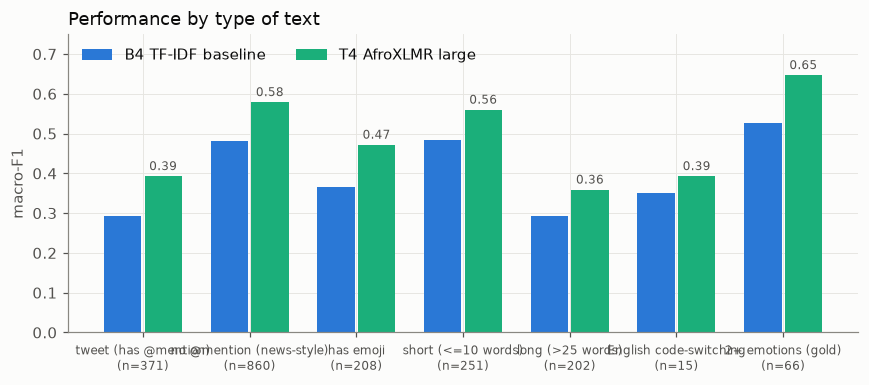

,slice,n_texts,B4,L3,T1,T2,T3,T4
0,tweet (has @mention),371,0.293,0.314,0.210,0.301,0.358,0.393
1,no @mention (news-style),860,0.481,0.446,0.324,0.501,0.520,0.579
2,has emoji,208,0.366,0.344,0.244,0.325,0.383,0.472
3,short (<=10 words),251,0.485,0.444,0.337,0.425,0.471,0.560
4,long (>25 words),202,0.294,0.327,0.222,0.348,0.324,0.359
5,English code-switching,15,0.350,0.177,0.196,0.217,0.317,0.393
6,no emotion (gold),354,0.274,0.322,0.099,0.305,0.345,0.404
7,2+ emotions (gold),66,0.527,0.509,0.511,0.568,0.509,0.647


In [10]:
sl = pd.read_csv("results/error_analysis/slices.csv")
sl.columns = [c.split("_")[0] if c[:2] in ("B4", "L3", "T1", "T2", "T3", "T4") else c for c in sl.columns]
show = sl[~sl.slice.str.startswith("no emotion")].set_index("slice")[["n_texts", "B4", "T4"]]
fig, ax = plt.subplots(figsize=(8, 3.6))
x = np.arange(len(show)); w = 0.38
b1 = ax.bar(x - w / 2, show["B4"], w - 0.03, color=SERIES[0], label="B4 TF-IDF baseline")
b2 = ax.bar(x + w / 2, show["T4"], w - 0.03, color=SERIES[2], label="T4 AfroXLMR large")
ax.bar_label(b2, fmt="%.2f", fontsize=8, color="#52514e", padding=2)
ax.set_xticks(x, [f"{s}\n(n={n})" for s, n in zip(show.index, show.n_texts)], fontsize=8)
ax.set_ylabel("macro-F1"); ax.set_ylim(0, 0.75); ax.legend(frameon=False, ncol=2)
ax.set_title("Performance by type of text", loc="left")
plt.tight_layout(); plt.savefig("results/figures/slices.png", dpi=150); plt.show()
sl

- **Tweets are much harder than news-style sentences** (0.39 vs 0.58 for the best model): slang, sarcasm, mocking replies, missing context.
- The "English code-switching" slice has only 15 texts, **too few to conclude anything**.
- Texts with **no** emotion are left empty only ~40% of the time by the best model. That is the cost of low thresholds for rare emotions: better recall, more false alarms.

## 6. What did the baseline learn? (a shortcut)
Top-weighted features of the TF-IDF model for each emotion (refit here, ~20 s).

In [11]:
from sklearn.pipeline import FeatureUnion, Pipeline
from src.baseline import char_tfidf, ovr_logreg, word_tfidf
train = pd.read_csv(PROCESSED_DIR / "train.csv")
pipe = Pipeline([("tfidf", FeatureUnion([("word", word_tfidf()), ("char", char_tfidf())])), ("clf", ovr_logreg(True))])
pipe.fit(train["clean_text"], train[EMOTIONS])
names = np.array([n.split("__", 1)[1] for n in pipe.named_steps["tfidf"].get_feature_names_out()])
pd.DataFrame({e: names[np.argsort(est.coef_[0])[-10:][::-1]] for e, est in zip(EMOTIONS, pipe.named_steps["clf"].estimators_)})

,anger,disgust,fear,joy,sadness,surprise
0,?,kurya,ubwoba,shim,😭,agiye
1,cg,isesemi,impungenge,iza,bab,tungu
2,eb,amashyira,ko,him,ara,bashyiraho
3,ntabwo,unuk,ari ikibazo,za,we,il
4,😂,nuk,ubwob,iyi,ari,kurema leta
5,c,unu,ingaruka,url,ya,kurema
6,?,ibihitwe,bwob,nziza,ab,mu yindi
7,karye,umunuko,bwoba,cyane,we,rwanda .
8,agir,umuziha,woba,🙏,birababaje,agi
9,koko,rya,wob,ku,baba,tung


Meaningful words appear (*ubwoba* fear, *impungenge* worry, *birababaje* it is sad, *shimira* thank,
*umwanda* dirt, 😭), but so do **style cues**: the top anger features include `?`, `cg`, `😂`. Anger
texts are mostly mocking @replies, so the models learn "reply + question + laughing emoji = anger".
Jokes are therefore misread as anger: the hard cases below include several.

## 7. Word2Vec: what the embeddings learned
Nearest neighbours (cosine similarity) in the 100-d skip-gram vectors trained on 4.4M words of KINNEWS news text.

In [12]:
print(open("results/word2vec_neighbours.txt", encoding="utf-8").read())

ubwoba       -> ikimuteye, bibateye, ishozi, yabivugaga, bahahamutse, mpuye, isoni, ukuntu
agahinda     -> intimba, gahinda, ishavu, gakabije, akababaro, umubabaro, amarira, bitashye
ibyishimo    -> umunezero, bitashye, bisendereye, akanyamuneza, ibigeragezo, yishima, bimushimisha, rudasanzwe
umujinya     -> umuranduranzuzi, akavuka, uburakari, gatuza, yarakaye, ndeke, ntabura, yabivugaga
umwanda      -> amasazi, umunuko, mwanda, amavunja, igitaka, byaterwa, ibyonnyi, dusimba
birababaje   -> pee, bizoroha, twakabaye, mpuye, nibutse, tumenye, turamutse, ikibabaza
nziza        -> mbi, turatera, bamwifurije, kubifuriza, isura, mwihangana, kwifuriza, kumwifuriza
urupfu       -> rupfu, rutunguranye, rubabaje, mugororwa, rwashenguye, ruhuriye, yapfuye, apfe
ikibazo      -> kibazo, gihari, igisubizo, cyakemuka, gukemuka, kukibona, ibibazo, kidukomereye
umukino      -> mukino, ishiraniro, ishyiraniro, wahuje, ikina, wakinwe, uzabahuza, itazakina


*agahinda* (grief) sits next to *intimba, ishavu, akababaro, amarira* (sorrow, pain, tears). But *nziza* (good) has
**mbi (bad)** as its nearest neighbour. Opposites occur in the same contexts, so distributional vectors place
them together, which is a weakness for emotion polarity (joy vs sadness).

## 8. Hard cases: wrong for every model
Texts that all six analysed models get wrong. 21 were reviewed by a native Kinyarwanda speaker in `results/error_analysis/native_speaker_review.csv`.

In [13]:
review = pd.read_csv("results/error_analysis/native_speaker_review.csv", encoding="utf-8-sig")
review["text"] = review["text"].str.replace("@<username>", "@user").str.replace("##url##", "URL")
review[["no", "text", "gold", "AfroXLMR_large_said", "your_judgement", "notes"]]

,no,text,gold,AfroXLMR_large_said,your_judgement,notes
0,1,ubundi the so-called big fish idafite amafaranga kuri njye nyifata nk'ururagara. uko ni ukuri kandi twumve...,anger,none,NaN,NaN
1,2,uretse mu ikinamico wari wabona ahandi hanu umukobwa yanze umusore wumukire agasanga uwumukene 😒😒,anger,sadness+surprise,NaN,NaN
2,3,nizere ko babantu bafashaga mama kumfata agiye kunkubita ubu bakora muri cia na fbi😭😭 ibigome gusa😩,anger,sadness,NaN,NaN
3,4,@user ariko buriya nawe wagombye gukurikira abandi. kuko ndabona ukurikira bake pe!!! ibyo bagukorera nawe...,sadness,anger,NaN,NaN
4,5,@user @user wishyire wizane muri byose urangwe nishyaka uterimbere none uraganje mubwigenge tugukomeyeho u...,joy,anger,NaN,NaN
5,6,kwinjira muri iki gitaramo bisaba kwishyura ibihumbi 10frw ubundi ukayanywera wumva icyanga cya amstel.,joy,none,NaN,NaN
6,7,"ugereranyije n’ubwiyongere bw’abaturage, abashora imari mu kubaka inzu ziciriritse n’iz’ubucuruzi baba bake.",fear,none,NaN,NaN
7,8,"nubwo bigaragara ko ibyagezweho mu buryo bw’imibare mu gihe gito ari byiza, haracyari icyuho kinini ugerer...",fear,none,NaN,NaN
8,9,yasabye ababyeyi b’abana gukomeza kubitaho babaha uburere bukwiye kuko imyaka bagezemo ari bwo bamwe batan...,fear,none,NaN,NaN
9,10,"ahantu honyine guterres avuga u rwanda, ni aho agaragaza ko umubano warwo na congo wazambye nyuma y’uko m2...",surprise,sadness,NaN,NaN


In [14]:
if review["your_judgement"].fillna("").str.strip().ne("").any():
    print(review["your_judgement"].str.strip().str[0].value_counts().rename(
        {"A": "label debatable", "B": "sarcasm / joke", "C": "needs context", "D": "slang / code-switching", "E": "model wrong"}))
else:
    print("Native-speaker judgements not filled in yet.")

Native-speaker judgements not filled in yet.


## Summary

1. **Best model:** AfroXLMR-large, test macro-F1 **0.592 ± 0.006**, +0.08 over the TF-IDF baseline and +0.23 over XLM-R.
2. **Language-specific pretraining matters more than architecture:** the same architecture gains +0.17 from African-language pretraining.
3. **Simple baselines are strong with little data:** TF-IDF beats every BiLSTM, and the cheapest fix (class weights + thresholds) is the biggest gain.
4. **Remaining errors** are misses on subtle texts, anger/sadness overlap, tweets with sarcasm or jokes, rare surprise, and labels that even humans may dispute.